<a href="https://colab.research.google.com/github/LadyAlena/KAN/blob/main/KAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 5.1 MB/s eta 0:00:00


In [2]:
from kan import *

torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


Создаем модель KAN

In [3]:
model = KAN(width=[2, 5, 1], grid=5, k=3, seed=43, device=device)

checkpoint directory created: ./model
saving model version 0.0


Создаем датасет

In [4]:
from kan.utils import create_dataset
# f(x, y) = exp(sin(pi*x) + y^2)
f = lambda x: torch.exp(torch.sin(torch.pi * x[:, [0]]) + x[:, [1]]**2)
dataset = create_dataset(f, n_var=2, device=device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

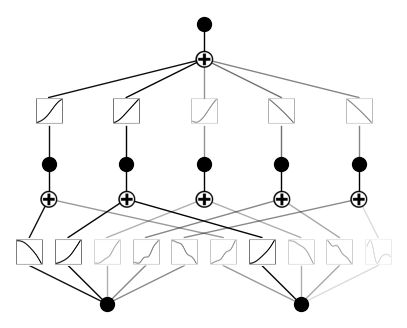

In [6]:
model(dataset['train_input']);
model.plot()

Обучение KAN с помощью регуляризации разреженности

In [7]:
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001);

| train_loss: 2.19e-02 | test_loss: 2.28e-02 | reg: 1.03e+01 | : 100%|█| 50/50 [00:20<00:00,  2.39it

saving model version 0.1


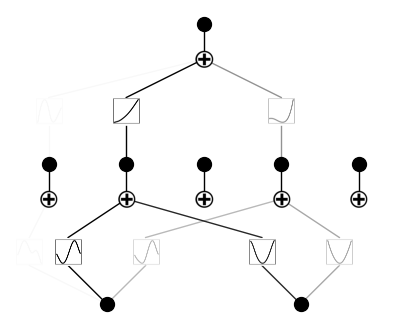

In [8]:
model.plot()

Обрезаем связи в KAN

saving model version 0.3


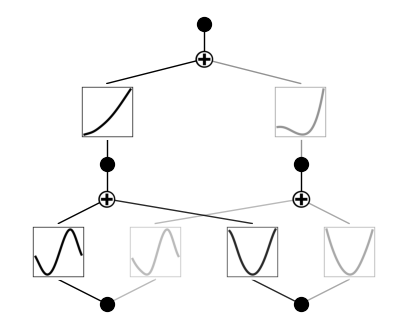

In [10]:
model = model.prune()
model.plot()

Дообучение

In [11]:
model.fit(dataset, opt="LBFGS", steps=50);

| train_loss: 4.22e-03 | test_loss: 4.58e-03 | reg: 1.22e+01 | : 100%|█| 50/50 [00:14<00:00,  3.50it

saving model version 0.4


In [12]:
model = model.refine(10);

saving model version 0.5


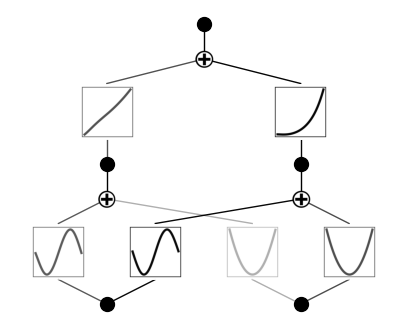

In [13]:
model.plot()

In [14]:
model.fit(dataset, opt="LBFGS", steps=50);

| train_loss: 3.85e-04 | test_loss: 4.32e-04 | reg: 1.22e+01 | : 100%|█| 50/50 [00:13<00:00,  3.61it

saving model version 0.6


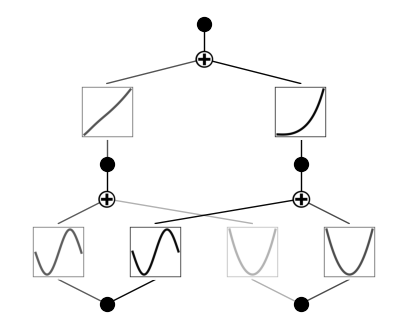

In [15]:
model.plot()